<a href="https://colab.research.google.com/github/jvit04/CursoIntroIA/blob/main/ClusterizacionK_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
datos= pd.read_csv("housing.csv")

In [3]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: xlabel='latitude', ylabel='longitude'>

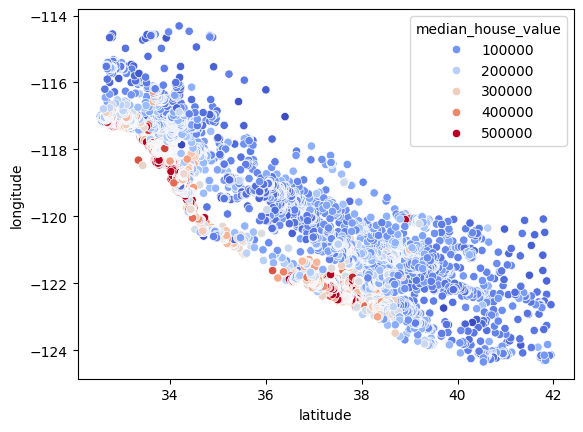

In [ ]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value", palette="coolwarm")

TypeError: cannot convert the series to <class 'float'>

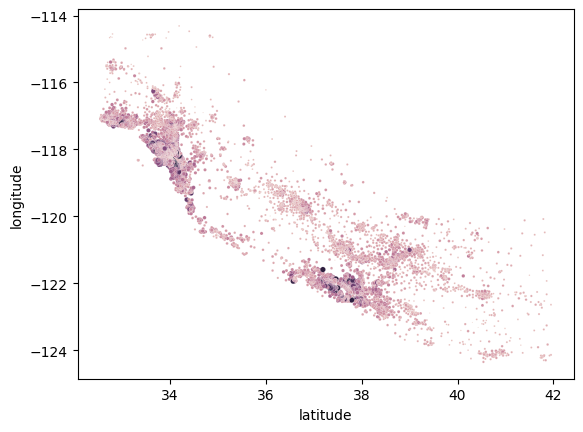

In [ ]:
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_income",
               s=datos['median_income'])

In [ ]:
datos.loc[:,['longitude','latitude', 'median_income']	]

,longitude,latitude,median_income
0,-122.23,37.88,8.3252
1,-122.22,37.86,8.3014
2,-122.24,37.85,7.2574
3,-122.25,37.85,5.6431
4,-122.25,37.85,3.8462
...,...,...,...
20635,-121.09,39.48,1.5603
20636,-121.21,39.49,2.5568
20637,-121.22,39.43,1.7000
20638,-121.32,39.43,1.8672


In [ ]:
from sklearn.cluster import KMeans
x = datos.loc[:,['longitude','latitude', 'median_income']	]
modelo = KMeans(n_clusters=6)
predicciones = modelo.fit_predict(x)

In [ ]:
predicciones.shape

(20640,)

In [ ]:
x["segmento_economico"] = predicciones

In [ ]:
x

,longitude,latitude,median_income,segmento_economico
0,-122.23,37.88,8.3252,3
1,-122.22,37.86,8.3014,3
2,-122.24,37.85,7.2574,3
3,-122.25,37.85,5.6431,3
4,-122.25,37.85,3.8462,1
...,...,...,...,...
20635,-121.09,39.48,1.5603,1
20636,-121.21,39.49,2.5568,1
20637,-121.22,39.43,1.7000,1
20638,-121.32,39.43,1.8672,1


In [ ]:
x["segmento_economico"].value_counts()

,count
segmento_economico,
0,6995
1,4884
4,3857
3,2763
5,1683
2,458


<Axes: xlabel='latitude', ylabel='longitude'>

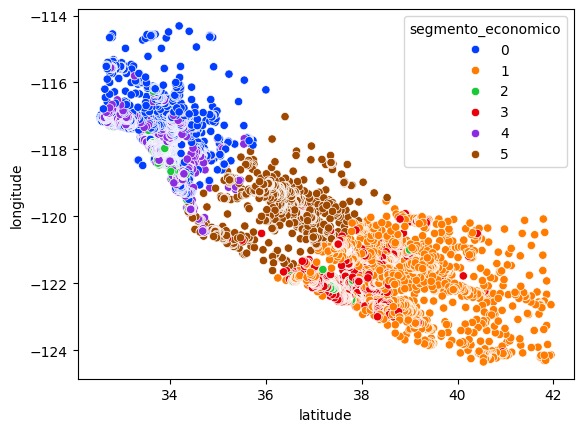

In [ ]:
sb.scatterplot(x="latitude", y="longitude", data=x, hue="segmento_economico",
               palette="bright")

<Axes: xlabel='segmento_economico', ylabel='count'>

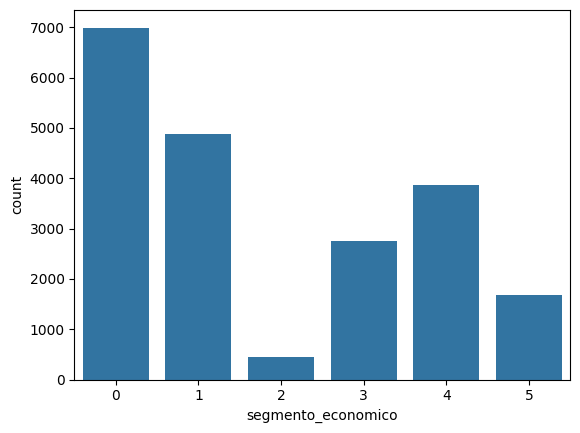

In [ ]:
sb.countplot(x="segmento_economico",data=x)

In [ ]:
x.groupby(["segmento_economico"])["median_income"].mean()

,median_income
segmento_economico,
0,2.870170
1,2.824422
2,10.950196
3,5.522754
4,5.510658
5,2.667951


Como parte de la lección "Ejercicio de clusterización con K-means", realizaste una clusterización basada en el segmento económico, utilizando el dato de median_income.

Utiliza ese mismo proceso, pero esta vez realiza una clusterización basada en la cantidad de personas que vive en las casas.

Considera que cuentas con los datos “population” y “households”, por lo que podrías crear un nuevo dato para el conjunto llamado pop_per_household (o población por casa), cuyo valor sea el valor de population / households. Esto nos dará un promedio de cuantas personas viven en las casas.

Similar a la lección, realiza clusterizaciones con distintos números de clústers y visualiza el mapa para analizar los resultados.

In [5]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: xlabel='latitude', ylabel='longitude'>

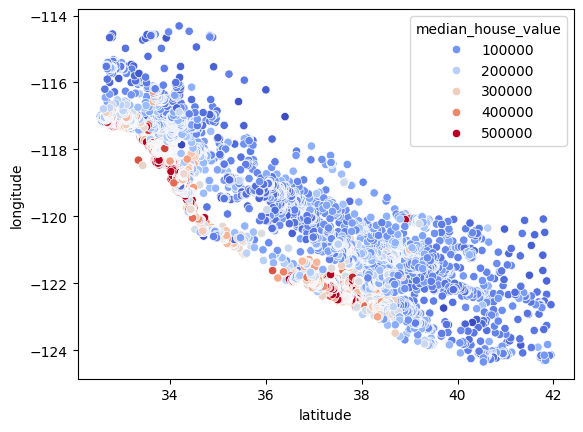

In [4]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value", palette="coolwarm")

TypeError: cannot convert the series to <class 'float'>

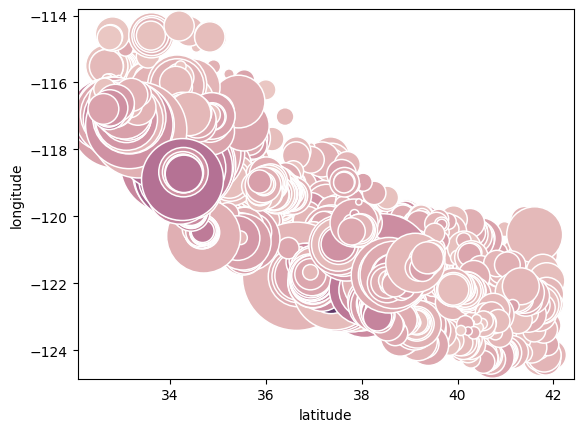

In [6]:
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_income",s=datos["households"])

In [31]:
#revisar si en households no hay datos que son igual a 0, ya que esto puede causar conflicto con pop_per_household
datos[datos["households"]==0]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,pop_per_household


In [7]:
#crear dato de poblacion por casa population/households
pop_per_household = datos["population"]/datos["households"]
datos["pop_per_household"] = pop_per_household

In [34]:
from sklearn.cluster import KMeans
x = datos.loc[:,['population','households', 'pop_per_household']	]
modelo = KMeans(n_clusters=4)
predicciones = modelo.fit_predict(x)

In [9]:
predicciones.shape

(20640,)

In [35]:
x["segmento_poblacional"] = predicciones

In [36]:
x["segmento_poblacional"].value_counts()

,count
segmento_poblacional,
0,11513
1,7114
3,1794
2,219


<Axes: xlabel='households', ylabel='population'>

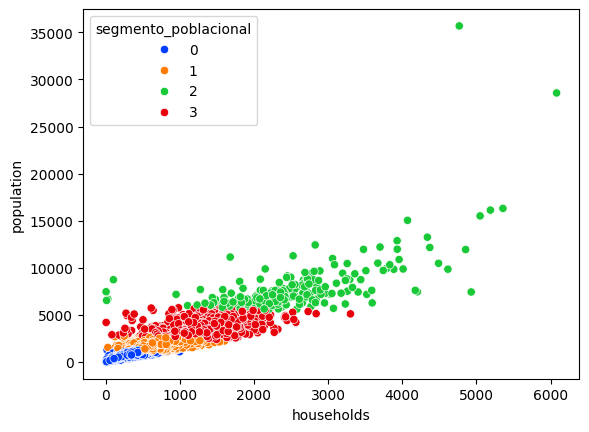

In [37]:
sb.scatterplot(x="households", y="population", data=x, hue="segmento_poblacional",
               palette="bright")

<Axes: xlabel='segmento_poblacional', ylabel='count'>

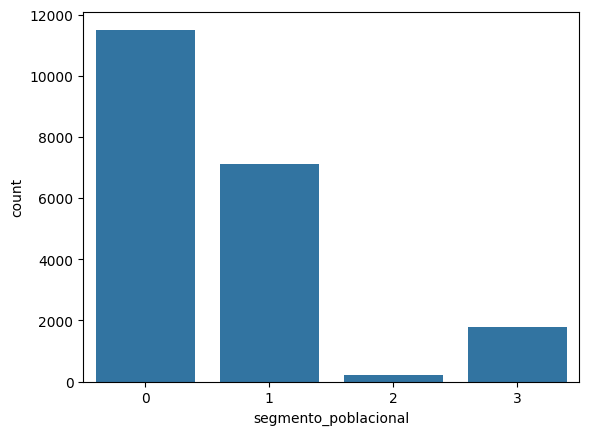

In [38]:
sb.countplot(x="segmento_poblacional",data=x)

In [33]:
x.describe()

,population,households,pop_per_household,segmento_poblacional
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,1425.476744,499.539680,3.070655,1.159157
std,1132.462122,382.329753,10.386050,1.354150
min,3.000000,1.000000,0.692308,0.000000
25%,787.000000,280.000000,2.429741,0.000000
50%,1166.000000,409.000000,2.818116,1.000000
75%,1725.000000,605.000000,3.282261,1.000000
max,35682.000000,6082.000000,1243.333333,5.000000


In [39]:
x.groupby(["segmento_poblacional"])["households"].mean()

,households
segmento_poblacional,
0,295.762356
1,603.166151
2,2520.826484
3,1149.610925
